# Logistic Regression (Using Sklearn)

**File required:** `Social_Network_Ads.csv` (same folder as this notebook)

The same problem as the scratch notebook, but the model is now the ready-made `LogisticRegression` from scikit-learn. The data preparation is the same; only the model changes. Here `Gender` is converted with `LabelEncoder` (Female → 0, Male → 1).

## Step 1 — Imports and loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

data = pd.read_csv("Social_Network_Ads.csv")

# Encode Gender (Female -> 0, Male -> 1)
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15571211,1,38,76000,0
1,15813763,1,41,83000,1
2,15719316,1,35,57000,0
3,15747734,1,28,105000,1
4,15594357,1,33,77000,0


## Step 2 — Features, target, train/test split and scaling

In [2]:
X = data[["Gender", "Age", "EstimatedSalary"]].values
y = data["Purchased"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 3 — Train the model and predict

In [3]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Weights:", model.coef_[0])
print("Bias   :", model.intercept_[0])

Weights: [0.18637064 1.73092825 1.07520157]
Bias   : -1.8354361495702123


## Step 4 — Evaluate

In [4]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8375
Confusion Matrix:
 [[55  2]
 [11 12]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89        57
           1       0.86      0.52      0.65        23

    accuracy                           0.84        80
   macro avg       0.85      0.74      0.77        80
weighted avg       0.84      0.84      0.82        80



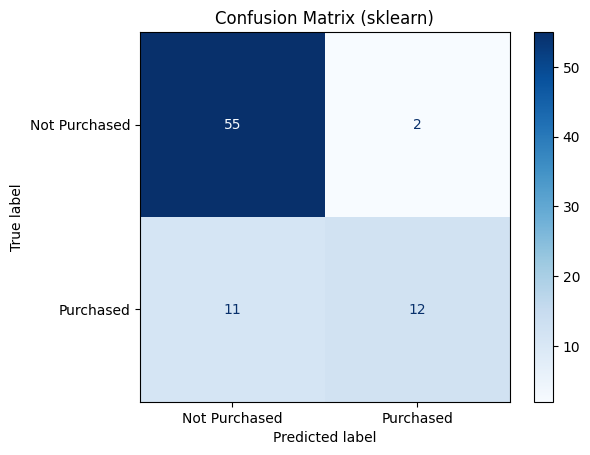

In [5]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Not Purchased", "Purchased"]).plot(cmap="Blues")
plt.title("Confusion Matrix (sklearn)")
plt.show()

## Step 5 — Compare with the from-scratch model

Both models solve the same problem with the same data and the same gradient-based idea, so their weights and accuracy should be very close. Small differences come from sklearn applying L2 regularization by default and using a different optimizer.

In [6]:
class ScratchLogReg:
    def __init__(self, lr=0.1, iters=1000):
        self.lr, self.iters = lr, iters
    def fit(self, X, y):
        m, k = X.shape
        self.w, self.b = np.zeros(k), 0
        for _ in range(self.iters):
            p = 1 / (1 + np.exp(-(X @ self.w + self.b)))
            self.w -= self.lr * (X.T @ (p - y)) / m
            self.b -= self.lr * np.sum(p - y) / m
    def predict(self, X):
        return (1 / (1 + np.exp(-(X @ self.w + self.b))) > 0.5).astype(int)

scratch = ScratchLogReg()
scratch.fit(X_train, y_train)

comparison = pd.DataFrame({
    "Scratch weights": scratch.w,
    "Sklearn weights": model.coef_[0]
}, index=["Gender", "Age", "EstimatedSalary"])
display(comparison.round(4))

print("Scratch accuracy:", accuracy_score(y_test, scratch.predict(X_test)))
print("Sklearn accuracy:", accuracy_score(y_test, y_pred))

,Scratch weights,Sklearn weights
Gender,0.1966,0.1864
Age,1.8103,1.7309
EstimatedSalary,1.1238,1.0752


Scratch accuracy: 0.85
Sklearn accuracy: 0.8375


### Interpretation
Using sklearn gives the same result with far less code, and adds extras such as regularization and multiple solvers. Writing it from scratch (previous notebook) shows what actually happens inside `fit()`.